In [1]:
import pandas as pd
raw_trails = pd.read_json("https://raw.githubusercontent.com/j-ane/trail-data/refs/heads/master/State%20Trail%20Data/California.json")

In [2]:
raw_trails.head(5)

,objectID,ID,slug,name,popularity,type,_geoloc,length,elevation_gain,difficulty_rating,...,feature_names,activity_names,overview,num_reviews,units,area_slug,trail_id,city_url,park_slug,profile_photo_url
0,trail-10026910,10026910,us/california/vernal-and-nevada-falls-via-the-...,Vernal and Nevada Falls via the Mist Trail,68.1488,trail,"{'lat': 37.73495, 'lng': -119.56619}",10299.776,667.8168,3,...,"[Dogs No, Forest, Partially Paved, River, View...","[Bird Watching, Hiking, Nature Trips, Walking]",NaN,1869,i,parks/us/california/yosemite-national-park,10026910,us/california/yosemite-valley,us/california/yosemite-national-park,https://cdn-assets.alltrails.com/uploads/photo...
1,trail-10111800,10111800,us/california/potato-chip-rock-via-mt-woodson-...,Potato Chip Rock via Mt. Woodson Trail,64.4194,trail,"{'lat': 33.00428, 'lng': -117.01322}",12230.984,641.9088,5,...,"[Dogs Leash, Lake, Views, Wild Flowers, Wildlife]","[Hiking, Mountain Biking, Nature Trips]",NaN,2756,i,parks/us/california/lake-poway-park,10111800,us/california/poway,us/california/lake-poway-park,https://cdn-assets.alltrails.com/uploads/photo...
2,trail-10031492,10031492,us/california/eaton-canyon-trail,Eaton Canyon Trail,59.3490,trail,"{'lat': 34.17812, 'lng': -118.09664}",5632.690,132.8928,3,...,"[Cave, Dogs Leash, Forest, Kid Friendly, River...","[Hiking, Running]",NaN,2084,i,parks/us/california/eaton-canyon-natural-area-...,10031492,us/california/pasadena,us/california/eaton-canyon-natural-area-park,https://cdn-assets.alltrails.com/uploads/photo...
3,trail-10027227,10027227,us/california/alamere-falls-via-coast-trail-fr...,Alamere Falls via Coast Trail from Palomarin T...,57.6980,trail,"{'lat': 37.9339, 'lng': -122.74668}",14162.192,406.9080,3,...,"[Beach, Dogs No, Forest, Lake, Views, Waterfal...","[Bird Watching, Hiking, Nature Trips]",NaN,1826,i,parks/us/california/point-reyes-national-seashore,10027227,us/california/bolinas,us/california/point-reyes-national-seashore,https://cdn-assets.alltrails.com/uploads/photo...
4,trail-10005895,10005895,us/california/upper-yosemite-falls-trail,Upper Yosemite Falls Trail,53.6280,trail,"{'lat': 37.74237, 'lng': -119.60223}",11587.248,967.7400,7,...,"[Dogs No, Forest, River, Views, Waterfall, Wil...","[Bird Watching, Hiking, Nature Trips, Running]",NaN,1351,i,parks/us/california/yosemite-national-park,10005895,us/california/yosemite-valley,us/california/yosemite-national-park,https://cdn-assets.alltrails.com/uploads/photo...


#Cleaning Dataset
normalizing values, removing duplicate columns/rows, handling blanks

In [3]:
#Pandas sometimes doesn't treat '' as NaaN or Null, so make it null
raw_trails.replace('',pd.NA, inplace=True)

In [4]:
raw_trails.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9019 entries, 0 to 9018
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   objectID           9019 non-null   object 
 1   ID                 9019 non-null   int64  
 2   slug               9019 non-null   object 
 3   name               9019 non-null   object 
 4   popularity         9019 non-null   float64
 5   type               9019 non-null   object 
 6   _geoloc            9019 non-null   object 
 7   length             9019 non-null   float64
 8   elevation_gain     9019 non-null   float64
 9   difficulty_rating  9019 non-null   int64  
 10  route_type         9019 non-null   object 
 11  visitor_usage      8127 non-null   object 
 12  avg_rating         9019 non-null   float64
 13  area_id            7823 non-null   float64
 14  area_name          7823 non-null   object 
 15  country_id         9019 non-null   int64  
 16  country_name       9019 

In [5]:
#Add to missing city name
raw_trails[raw_trails['city_name'].isna()]

,objectID,ID,slug,name,popularity,type,_geoloc,length,elevation_gain,difficulty_rating,...,feature_names,activity_names,overview,num_reviews,units,area_slug,trail_id,city_url,park_slug,profile_photo_url
8699,trail-10541176,10541176,us/california/la-jolla-heights-preserve-walk,La Jolla Heights Preserve Walk,1.1943,trail,"{'lat': 32.84374, 'lng': -117.26494}",1931.208,104.8512,3,...,"[Views, Wild Flowers]","[Hiking, Nature Trips, Walking]",NaN,2,i,parks/us/california/la-jolla-natural-park,10541176,us/california/---3,us/california/la-jolla-natural-park,https://cdn-assets.alltrails.com/uploads/photo...


In [6]:
raw_trails.loc[raw_trails['ID']==10541176, 'city_name'] = 'San Diego'
raw_trails[raw_trails['ID']==10541176][['name', 'city_name']]

,name,city_name
8699,La Jolla Heights Preserve Walk,San Diego


In [7]:
no_name = raw_trails[raw_trails['area_name'].isna()]
no_name.head(3)
#trails that don't have an area name also don't have area or park slug

,objectID,ID,slug,name,popularity,type,_geoloc,length,elevation_gain,difficulty_rating,...,feature_names,activity_names,overview,num_reviews,units,area_slug,trail_id,city_url,park_slug,profile_photo_url
7,trail-10027021,10027021,us/california/iron-mountain-trail--5,Iron Mountain Trail,52.6989,trail,"{'lat': 32.97817, 'lng': -116.97242}",8368.568,335.8896,3,...,"[Dogs Leash, Kid Friendly, Views, Wild Flowers]","[Hiking, Mountain Biking, Running]",NaN,1907,i,<NA>,10027021,us/california/poway,NaN,https://cdn-assets.alltrails.com/uploads/photo...
63,trail-10021855,10021855,us/california/santa-margarita-river-trail,Santa Margarita River Trail,34.2434,trail,"{'lat': 33.41328, 'lng': -117.24133}",8046.700,142.9512,3,...,"[Dogs Leash, Forest, Kid Friendly, River, View...","[Hiking, Mountain Biking, Nature Trips, Runnin...",NaN,756,i,<NA>,10021855,us/california/fallbrook,NaN,https://cdn-assets.alltrails.com/uploads/photo...
126,trail-10031222,10031222,us/california/woodson-mountain-and-potato-chip...,Woodson Mountain and Potato Chip Rock via Hwy 67,28.3650,trail,"{'lat': 33.00833, 'lng': -116.95541}",6598.294,371.8560,3,...,"[Cave, Dogs Leash, Kid Friendly, Paved, Views,...","[Hiking, Nature Trips, Walking]",NaN,695,i,<NA>,10031222,us/california/ramona,NaN,https://cdn-assets.alltrails.com/uploads/photo...


In [8]:
#Duplicates
display(raw_trails[raw_trails.objectID.duplicated()])
print("** row 419, 420 are duplicates of another row **")
display(raw_trails[raw_trails.objectID == "trail-10183081"])
print("** row 419, 420 are duplicates of row 418 **")


,objectID,ID,slug,name,popularity,type,_geoloc,length,elevation_gain,difficulty_rating,...,feature_names,activity_names,overview,num_reviews,units,area_slug,trail_id,city_url,park_slug,profile_photo_url
419,trail-10183081,10183081,us/california/lake-murray-trail,Lake Murray Trail,19.3346,trail,"{'lat': 32.78571, 'lng': -117.03853}",9495.106,35.9664,1,...,"[Wheelchair Friendly, Dogs Leash, Lake, Kid Fr...","[Bird Watching, Fishing, Hiking, Nature Trips,...",NaN,289,i,parks/us/california/lake-murray-community-park,10183081,us/california/la-mesa,us/california/lake-murray-community-park,https://cdn-assets.alltrails.com/uploads/photo...
420,trail-10183081,10183081,us/california/lake-murray-trail,Lake Murray Trail,19.3346,trail,"{'lat': 32.78571, 'lng': -117.03853}",9495.106,35.9664,1,...,"[Wheelchair Friendly, Dogs Leash, Lake, Kid Fr...","[Bird Watching, Fishing, Hiking, Nature Trips,...",NaN,289,i,parks/us/california/lake-murray-community-park,10183081,us/california/la-mesa,us/california/lake-murray-community-park,https://cdn-assets.alltrails.com/uploads/photo...


** row 419, 420 are duplicates of another row **


,objectID,ID,slug,name,popularity,type,_geoloc,length,elevation_gain,difficulty_rating,...,feature_names,activity_names,overview,num_reviews,units,area_slug,trail_id,city_url,park_slug,profile_photo_url
418,trail-10183081,10183081,us/california/lake-murray-trail,Lake Murray Trail,19.3346,trail,"{'lat': 32.78571, 'lng': -117.03853}",9495.106,35.9664,1,...,"[Wheelchair Friendly, Dogs Leash, Lake, Kid Fr...","[Bird Watching, Fishing, Hiking, Nature Trips,...",NaN,289,i,parks/us/california/lake-murray-community-park,10183081,us/california/la-mesa,us/california/lake-murray-community-park,https://cdn-assets.alltrails.com/uploads/photo...
419,trail-10183081,10183081,us/california/lake-murray-trail,Lake Murray Trail,19.3346,trail,"{'lat': 32.78571, 'lng': -117.03853}",9495.106,35.9664,1,...,"[Wheelchair Friendly, Dogs Leash, Lake, Kid Fr...","[Bird Watching, Fishing, Hiking, Nature Trips,...",NaN,289,i,parks/us/california/lake-murray-community-park,10183081,us/california/la-mesa,us/california/lake-murray-community-park,https://cdn-assets.alltrails.com/uploads/photo...
420,trail-10183081,10183081,us/california/lake-murray-trail,Lake Murray Trail,19.3346,trail,"{'lat': 32.78571, 'lng': -117.03853}",9495.106,35.9664,1,...,"[Wheelchair Friendly, Dogs Leash, Lake, Kid Fr...","[Bird Watching, Fishing, Hiking, Nature Trips,...",NaN,289,i,parks/us/california/lake-murray-community-park,10183081,us/california/la-mesa,us/california/lake-murray-community-park,https://cdn-assets.alltrails.com/uploads/photo...


** row 419, 420 are duplicates of row 418 **


In [9]:
#Removing duplicate
raw_trails.drop_duplicates(subset='objectID', inplace=True)
print("Check deleted rows")
display(raw_trails[raw_trails["objectID"]=="trail-10183081"])

Check deleted rows


,objectID,ID,slug,name,popularity,type,_geoloc,length,elevation_gain,difficulty_rating,...,feature_names,activity_names,overview,num_reviews,units,area_slug,trail_id,city_url,park_slug,profile_photo_url
418,trail-10183081,10183081,us/california/lake-murray-trail,Lake Murray Trail,19.3346,trail,"{'lat': 32.78571, 'lng': -117.03853}",9495.106,35.9664,1,...,"[Wheelchair Friendly, Dogs Leash, Lake, Kid Fr...","[Bird Watching, Fishing, Hiking, Nature Trips,...",NaN,289,i,parks/us/california/lake-murray-community-park,10183081,us/california/la-mesa,us/california/lake-murray-community-park,https://cdn-assets.alltrails.com/uploads/photo...


In [10]:
#remove the outlier, Pacific Crest Trail since it's 2000+ miles
raw_trails[raw_trails['name'] == "Pacific Crest Trail"]
raw_trails.drop(index=1053, inplace=True)

In [11]:
#Some parks and trails have the same name, but they are in different areas
#ex: entral-park--14 and central-park-2 (in santa clarita and santa clara)
# but this is part of the actual url so we will keep it
print(raw_trails[raw_trails['area_slug'].str.contains('\d', na=False)][['area_name','area_slug']].nunique())
raw_trails[raw_trails['area_name']=='Central Park']
raw_trails[raw_trails['area_slug'].str.contains('central-park', na=False)]

area_name    59
area_slug    62
dtype: int64


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5508/3750842099.py:4: SyntaxWarning: invalid escape sequence '\d'
  print(raw_trails[raw_trails['area_slug'].str.contains('\d', na=False)][['area_name','area_slug']].nunique())


,objectID,ID,slug,name,popularity,type,_geoloc,length,elevation_gain,difficulty_rating,...,feature_names,activity_names,overview,num_reviews,units,area_slug,trail_id,city_url,park_slug,profile_photo_url
1655,trail-10022594,10022594,us/california/pacific-electric-trail,Pacific Electric Trail,10.9160,trail,"{'lat': 34.09529, 'lng': -117.70251}",29611.856,91.7448,1,...,"[Wheelchair Friendly, Dogs Leash, Kid Friendly...","[Bird Watching, Hiking, Nature Trips, Road Bik...",NaN,83,i,parks/us/california/rancho-cucamonga-central-park,10022594,us/california/rancho-cucamonga,us/california/rancho-cucamonga-central-park,https://cdn-assets.alltrails.com/uploads/photo...
1840,trail-10288298,10288298,us/california/lake-elizabeth--2,Lake Elizabeth,10.3828,trail,"{'lat': 37.54802, 'lng': -121.96591}",3379.614,2.7432,1,...,"[Wheelchair Friendly, Dogs Leash, Lake, Kid Fr...","[Bird Watching, Nature Trips, Running, Walking]",NaN,112,i,parks/us/california/fremont-central-park,10288298,us/california/fremont,us/california/fremont-central-park,https://cdn-assets.alltrails.com/uploads/photo...
2978,trail-10018591,10018591,us/california/shipley-nature-trail,Shipley Nature Trail,7.7428,trail,"{'lat': 33.69935, 'lng': -118.01043}",1770.274,4.8768,1,...,"[Dogs No, Lake, Kid Friendly, Views, Wildlife]","[Bird Watching, Hiking, Nature Trips, Walking]",NaN,40,i,parks/us/california/huntington-central-park,10018591,us/california/huntington-beach,us/california/huntington-central-park,https://cdn-assets.alltrails.com/uploads/photo...
4647,trail-10289497,10289497,us/california/central-park-loop,Central Park Loop,5.5105,trail,"{'lat': 34.43031, 'lng': -118.52452}",2253.076,77.7240,3,...,"[Dogs Leash, Kid Friendly, Views]","[Bird Watching, Hiking, Nature Trips, Running,...",NaN,34,i,parks/us/california/central-park--14,10289497,us/california/santa-clarita,us/california/central-park--14,https://cdn-assets.alltrails.com/uploads/photo...
5745,trail-10289731,10289731,us/california/central-park-lower-loop,Central Park Lower Loop,4.4028,trail,"{'lat': 34.43423, 'lng': -118.52324}",5954.558,120.7008,3,...,"[Dogs Leash, Kid Friendly, Views]","[Bird Watching, Hiking, Nature Trips, Running,...",NaN,21,i,parks/us/california/central-park--14,10289731,us/california/santa-clarita,us/california/central-park--14,https://cdn-assets.alltrails.com/uploads/photo...
7418,trail-10346064,10346064,us/california/central-park-loop--2,Central Park Loop,2.7551,trail,"{'lat': 37.34168, 'lng': -121.97451}",2896.812,3.9624,1,...,"[Wheelchair Friendly, Lake, Kid Friendly, Pave...","[Bird Watching, Running, Walking]",NaN,7,i,parks/us/california/central-park--2,10346064,us/california/santa-clara,us/california/central-park--2,https://cdn-assets.alltrails.com/uploads/photo...


In [12]:
raw_trails[raw_trails['area_slug'].str.contains('central-park', na=False)]['area_name']

,area_name
1655,Rancho Cucamonga Central Park
1840,Fremont Central Park
2978,Huntington Central Park
4647,Central Park
5745,Central Park
7418,Central Park


New Columns
-


In [13]:
#Create 2 new separate columns for long and lat
#Column _geoloc is a dictionary of longitude and latitude
lat_list = []
long_list = []
for dictionaries in raw_trails['_geoloc']:
  lat_list.append(dictionaries['lat'])
  long_list.append(dictionaries['lng'])

raw_trails['latitude'] = lat_list
raw_trails['longitude'] = long_list
raw_trails.head(5)


,objectID,ID,slug,name,popularity,type,_geoloc,length,elevation_gain,difficulty_rating,...,overview,num_reviews,units,area_slug,trail_id,city_url,park_slug,profile_photo_url,latitude,longitude
0,trail-10026910,10026910,us/california/vernal-and-nevada-falls-via-the-...,Vernal and Nevada Falls via the Mist Trail,68.1488,trail,"{'lat': 37.73495, 'lng': -119.56619}",10299.776,667.8168,3,...,NaN,1869,i,parks/us/california/yosemite-national-park,10026910,us/california/yosemite-valley,us/california/yosemite-national-park,https://cdn-assets.alltrails.com/uploads/photo...,37.73495,-119.56619
1,trail-10111800,10111800,us/california/potato-chip-rock-via-mt-woodson-...,Potato Chip Rock via Mt. Woodson Trail,64.4194,trail,"{'lat': 33.00428, 'lng': -117.01322}",12230.984,641.9088,5,...,NaN,2756,i,parks/us/california/lake-poway-park,10111800,us/california/poway,us/california/lake-poway-park,https://cdn-assets.alltrails.com/uploads/photo...,33.00428,-117.01322
2,trail-10031492,10031492,us/california/eaton-canyon-trail,Eaton Canyon Trail,59.3490,trail,"{'lat': 34.17812, 'lng': -118.09664}",5632.690,132.8928,3,...,NaN,2084,i,parks/us/california/eaton-canyon-natural-area-...,10031492,us/california/pasadena,us/california/eaton-canyon-natural-area-park,https://cdn-assets.alltrails.com/uploads/photo...,34.17812,-118.09664
3,trail-10027227,10027227,us/california/alamere-falls-via-coast-trail-fr...,Alamere Falls via Coast Trail from Palomarin T...,57.6980,trail,"{'lat': 37.9339, 'lng': -122.74668}",14162.192,406.9080,3,...,NaN,1826,i,parks/us/california/point-reyes-national-seashore,10027227,us/california/bolinas,us/california/point-reyes-national-seashore,https://cdn-assets.alltrails.com/uploads/photo...,37.93390,-122.74668
4,trail-10005895,10005895,us/california/upper-yosemite-falls-trail,Upper Yosemite Falls Trail,53.6280,trail,"{'lat': 37.74237, 'lng': -119.60223}",11587.248,967.7400,7,...,NaN,1351,i,parks/us/california/yosemite-national-park,10005895,us/california/yosemite-valley,us/california/yosemite-national-park,https://cdn-assets.alltrails.com/uploads/photo...,37.74237,-119.60223


In [14]:
#Converting meters in the length to miles
def convert_meters_to_miles(length_entry):
  return round(length_entry/1609, 2)

raw_trails['length_miles'] = raw_trails['length'].apply(convert_meters_to_miles)
raw_trails[['length', 'length_miles']] #testing output

,length,length_miles
0,10299.776,6.4
1,12230.984,7.6
2,5632.690,3.5
3,14162.192,8.8
4,11587.248,7.2
...,...,...
9014,11909.116,7.4
9015,5471.756,3.4
9016,10299.776,6.4
9017,16737.136,10.4


In [15]:
#Convert elevation to feet as well
def convert_meters_to_ft(elevation_meters):
  return round(elevation_meters * 3.28084, 4)

raw_trails['elevation_gain_ft'] = raw_trails["elevation_gain"].apply(convert_meters_to_ft)
raw_trails[["elevation_gain", "elevation_gain_ft"]]

,elevation_gain,elevation_gain_ft
0,667.8168,2191.0001
1,641.9088,2106.0001
2,132.8928,436.0000
3,406.9080,1335.0000
4,967.7400,3175.0001
...,...,...
9014,413.9184,1358.0000
9015,102.7176,337.0000
9016,440.7408,1446.0000
9017,450.7992,1479.0000


In [16]:
#steepness column
raw_trails['steepness_ftmi'] = raw_trails['elevation_gain_ft']/raw_trails['length_miles']

In [17]:
#Shenandoah's Hiking difficulty (based on miles and elevation)
#See info here: https://www.nps.gov/shen/planyourvisit/how-to-determine-hiking-difficulty.htm
def shenandoah(length_miles, elevation_ft):
  score = (length_miles * elevation_ft * 2) ** 0.5
  if score < 50:
    return "easy"
  elif score <= 100:
    return "moderate"
  elif score <= 150:
    return "moderately strenuous"
  elif score <= 200:
    return "strenuous"
  else:
    return "very strenuous"
diff = raw_trails.apply(lambda x: shenandoah(x['length_miles'], x['elevation_gain_ft']), axis=1)
raw_trails['difficulty_category'] = diff

raw_trails['difficulty_category'].value_counts()

,count
difficulty_category,
easy,2601
moderate,2157
very strenuous,1931
moderately strenuous,1402
strenuous,925


In [18]:
raw_trails['difficulty_rating'].value_counts()
avg_len_cat = raw_trails.groupby('difficulty_category')['length_miles'].mean()
avg_elev_cat = raw_trails.groupby('difficulty_category')['elevation_gain_ft'].mean()

avg_len_rating = raw_trails.groupby('difficulty_rating')['length_miles'].mean()
avg_elev_rating = raw_trails.groupby('difficulty_rating')['elevation_gain_ft'].mean()

print(f"{avg_len_cat} \n {avg_elev_cat}")
print()
print(f"{avg_len_rating} \n {avg_elev_rating}")


difficulty_category
easy                     2.171473
moderate                 4.352712
moderately strenuous     6.571427
strenuous                8.874195
very strenuous          20.324272
Name: length_miles, dtype: float64 
 difficulty_category
easy                     198.146867
moderate                 690.652295
moderately strenuous    1225.728972
strenuous               1758.113583
very strenuous          4267.663530
Name: elevation_gain_ft, dtype: float64

difficulty_rating
1     3.804195
3     7.222306
5    15.125602
7    23.052491
Name: length_miles, dtype: float64 
 difficulty_rating
1     361.266200
3    1288.212957
5    3477.668368
7    6039.792649
Name: elevation_gain_ft, dtype: float64


In [19]:
def compare_score(difficulty, category):
  if difficulty == 1 and category =="easy":
    return True
  elif difficulty == 3 and category in ["moderate", "moderately strenuous"]:
    return True
  elif difficulty == 5 and category in ["moderately strenuous","strenuous"]:
    return True
  elif difficulty == 7 and category in ["strenuous", "very strenuous"]:
    return True
  else:
    return False

compare = raw_trails.apply(lambda x: compare_score(x['difficulty_rating'], x['difficulty_category']), axis=1)
print(compare.value_counts())

True     5212
False    3804
Name: count, dtype: int64


In [20]:
#quick check to see if labels align with assigned difficulty rating
import seaborn as sns

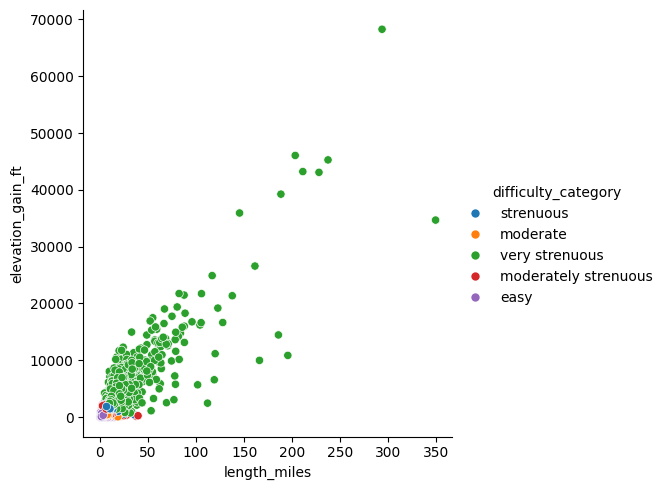

In [21]:
#Probably a better metric because longer and higher elevations are strenuous
sns.relplot(raw_trails, x="length_miles", y="elevation_gain_ft",
    hue="difficulty_category",
    sizes=(30, 150)
)

In [22]:
#categories of park, like state park, etc.
areas_mapped = {
    "State Park": "State Park",
    "County Park": "County Park",
    "National Park": "National Park",
    "Regional Park": "Regional Park",
    "Forest": "Forest",
    ("Base", "Fort", "Presidio"): "Fort",
    ("Rec. Area", "Recreation", "Ski Area", "Management Area"): "Recreation Area",
    "National Monument": "National Monument",
    "Park": "Park",
    ("Wilderness", "Reserve", "Preserve", "Canyon", "Refuge", "Wildlife Area", "Natural Area", "Hatchery", "Conservation Area"): "Protected Area",
    "Open Space": "Open Space",
    ("Unit", "Facility", "Center", "Municipal"): "Unit",
    ("Garden", "Arboretum"): "Garden",
    ("Shoreline", "Seashore", "Beach", "Headlands"): "Coast",
    ("Rancho", "Ranch"): "Ranch",
    "Reservation": "Reservation",
    ("Lake", "Marsh", "Watershed", "Wetlands", "Reservoir"): "Watershed"
}

In [23]:
#Typo: Wilderness is typed Wildemess
raw_trails[raw_trails['area_name'].str.contains("Wildemess", na=False)]["area_name"]
raw_trails.loc[[3496, 4257, 4706], "area_name"] = "Boney Mountain State Wilderness"

#raw_trails[raw_trails['area_name'].str.contains("Wildemess", na=False)]["area_name"]


In [24]:
#Type Arboretum as Aboretum
raw_trails[raw_trails['area_name'].str.contains("Aboretum", na=False)]["area_name"]
raw_trails.loc[[2773], "area_name"] = "Los Angeles County Arboretum"
#raw_trails.loc[[2773], "area_name"]

In [25]:
def map_to_area(area_name):
  if pd.isna(area_name):
    return "None"
  for key, value in areas_mapped.items():
    if isinstance(key, tuple):
      if any(k in area_name for k in key): #checking tuples
        return value
    elif key in area_name: #checking in single keys
        return value
  return "Other"

#map_to_area("Yosemite National Park")
names = raw_trails["area_name"].apply(map_to_area)
names
raw_trails["area_category"] = names
print(raw_trails["area_category"].value_counts())
raw_trails[["area_name", "area_category"]]

area_category
Forest               1598
Protected Area       1387
None                 1195
State Park           1094
Park                  907
National Park         707
Regional Park         655
Recreation Area       394
County Park           257
Coast                 171
National Monument     159
Open Space            121
Watershed             111
Unit                  103
Ranch                  52
Other                  48
Fort                   30
Reservation            14
Garden                 13
Name: count, dtype: int64


,area_name,area_category
0,Yosemite National Park,National Park
1,Lake Poway Park,Park
2,Eaton Canyon Natural Area Park,Park
3,Point Reyes National Seashore,Coast
4,Yosemite National Park,National Park
...,...,...
9014,Joseph D Grant County Park,County Park
9015,<NA>,None
9016,Mendocino National Forest,Forest
9017,Tahoe National Forest,Forest


In [26]:
raw_trails[raw_trails['area_category']=="Other"]['area_name']

,area_name
599,Tahoe Donner Trail System
616,San Joaquin Experimental Range
830,Hidden Villa
892,John Muir National Historic Site
993,Pillar Point Bluff
1418,Marina Green
1894,Tahoe Donner Trail System
2084,Sylvan Meadows
2257,MVTA Area Trails
2556,Hidden Villa


In [27]:
#change area_name blanks to Unlabeled
raw_trails["area_name"].replace(pd.NA, "Unlabeled", inplace=True)
len(raw_trails[raw_trails["area_name"]=="Unlabeled"])

/tmp/ipykernel_5508/49189294.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_trails["area_name"].replace(pd.NA, "Unlabeled", inplace=True)


1195

# Converting park/slug names
(editing and shortening slug/area names)

In [28]:
#strips the slug to only the last term, so park-name
#area_slug and park slug denote the same
def shorten_slug(slug_str):
  if pd.isna(slug_str):
    return "None"
  return slug_str.split("/")[-1]

raw_trails['area_slug'] = raw_trails['area_slug'].apply(shorten_slug)
raw_trails['park_slug'] = raw_trails['park_slug'].apply(shorten_slug)
not_nulls = raw_trails[(raw_trails['area_slug'] != "None") | (raw_trails['park_slug'] != "None")]
not_nulls[(not_nulls['area_slug'] == not_nulls['park_slug'])][['area_slug', 'park_slug']]

,area_slug,park_slug
0,yosemite-national-park,yosemite-national-park
1,lake-poway-park,lake-poway-park
2,eaton-canyon-natural-area-park,eaton-canyon-natural-area-park
3,point-reyes-national-seashore,point-reyes-national-seashore
4,yosemite-national-park,yosemite-national-park
...,...,...
9011,san-gabriel-mountains-national-monument--3,san-gabriel-mountains-national-monument--3
9014,joseph-d-grant-county-park,joseph-d-grant-county-park
9016,mendocino-national-forest,mendocino-national-forest
9017,tahoe-national-forest,tahoe-national-forest


In [29]:
#Url column that links to AllTrails
raw_trails['url'] = "https://www.alltrails.com/trail/" + raw_trails['slug']
raw_trails['url']

,url
0,https://www.alltrails.com/trail/us/california/...
1,https://www.alltrails.com/trail/us/california/...
2,https://www.alltrails.com/trail/us/california/...
3,https://www.alltrails.com/trail/us/california/...
4,https://www.alltrails.com/trail/us/california/...
...,...
9014,https://www.alltrails.com/trail/us/california/...
9015,https://www.alltrails.com/trail/us/california/...
9016,https://www.alltrails.com/trail/us/california/...
9017,https://www.alltrails.com/trail/us/california/...


#Finalized Table

In [30]:
#Finalized table
#Drop columns
filtered_cols = (raw_trails.drop(columns=['objectID','type','country_id',
'country_name','state_id','state_name','units','city_url','profile_photo_url',
'overview','area_slug','park_slug','trail_id','activity_names','feature_names',
'verified_map_id', 'slug', 'popularity', 'length', 'elevation_gain', 'area_id',
'city_id', '_geoloc']))

print(filtered_cols.info())
filtered_cols

<class 'pandas.core.frame.DataFrame'>
Index: 9016 entries, 0 to 9018
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   9016 non-null   int64  
 1   name                 9016 non-null   object 
 2   difficulty_rating    9016 non-null   int64  
 3   route_type           9016 non-null   object 
 4   visitor_usage        8124 non-null   object 
 5   avg_rating           9016 non-null   float64
 6   area_name            9016 non-null   object 
 7   city_name            9016 non-null   object 
 8   features             9016 non-null   object 
 9   activities           9016 non-null   object 
 10  num_reviews          9016 non-null   int64  
 11  latitude             9016 non-null   float64
 12  longitude            9016 non-null   float64
 13  length_miles         9016 non-null   float64
 14  elevation_gain_ft    9016 non-null   float64
 15  steepness_ftmi       9016 non-null   float6

,ID,name,difficulty_rating,route_type,visitor_usage,avg_rating,area_name,city_name,features,activities,num_reviews,latitude,longitude,length_miles,elevation_gain_ft,steepness_ftmi,difficulty_category,area_category,url
0,10026910,Vernal and Nevada Falls via the Mist Trail,3,L,3,5.0,Yosemite National Park,Yosemite Valley,"[dogs-no, forest, partially-paved, river, view...","[birding, hiking, nature-trips, walking]",1869,37.73495,-119.56619,6.4,2191.0001,342.343766,strenuous,National Park,https://www.alltrails.com/trail/us/california/...
1,10111800,Potato Chip Rock via Mt. Woodson Trail,5,O,4,4.5,Lake Poway Park,Poway,"[dogs-leash, lake, views, wild-flowers, wildlife]","[hiking, mountain-biking, nature-trips]",2756,33.00428,-117.01322,7.6,2106.0001,277.105276,strenuous,Park,https://www.alltrails.com/trail/us/california/...
2,10031492,Eaton Canyon Trail,3,O,4,4.0,Eaton Canyon Natural Area Park,Pasadena,"[cave, dogs-leash, forest, kids, river, views,...","[hiking, trail-running]",2084,34.17812,-118.09664,3.5,436.0000,124.571429,moderate,Park,https://www.alltrails.com/trail/us/california/...
3,10027227,Alamere Falls via Coast Trail from Palomarin T...,3,O,3,4.5,Point Reyes National Seashore,Bolinas,"[beach, dogs-no, forest, lake, views, waterfal...","[birding, hiking, nature-trips]",1826,37.93390,-122.74668,8.8,1335.0000,151.704545,strenuous,Coast,https://www.alltrails.com/trail/us/california/...
4,10005895,Upper Yosemite Falls Trail,7,O,3,5.0,Yosemite National Park,Yosemite Valley,"[dogs-no, forest, river, views, waterfall, wil...","[birding, hiking, nature-trips, trail-running]",1351,37.74237,-119.60223,7.2,3175.0001,440.972236,very strenuous,National Park,https://www.alltrails.com/trail/us/california/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9014,10543781,"Dairy, Dutch Flat and Brush Trail Loop",3,L,1,0.0,Joseph D Grant County Park,Mount Hamilton,"[dogs-leash, lake, views, wildlife]","[birding, camping, hiking, mountain-biking, ho...",0,37.32781,-121.71673,7.4,1358.0000,183.513514,moderately strenuous,County Park,https://www.alltrails.com/trail/us/california/...
9015,10545876,Piru Reasoner Canyon Trail [PRIVATE PROPERTY],1,O,1,0.0,Unlabeled,Piru,"[dogs, lake, kids, partially-paved, views, wil...","[birding, hiking, nature-trips, trail-running,...",0,34.47686,-118.76727,3.4,337.0000,99.117647,easy,None,https://www.alltrails.com/trail/us/california/...
9016,10544953,Mount Linn Loop,3,L,1,0.0,Mendocino National Forest,Red Bluff,"[lake, views, wild-flowers]","[backpacking, fishing, hiking]",0,40.03796,-122.82942,6.4,1446.0000,225.937500,moderately strenuous,Forest,https://www.alltrails.com/trail/us/california/...
9017,10545194,Crooked Lake and Grouse Ridge Loop,3,L,<NA>,5.0,Tahoe National Forest,Emigrant Gap,"[forest, lake, views, wild-flowers, wildlife]","[backpacking, camping, fishing, hiking]",4,39.39077,-120.60933,10.4,1479.0000,142.211538,strenuous,Forest,https://www.alltrails.com/trail/us/california/...


In [31]:
#export this as a csv file with some specified path in google drive
#make sure directory exists
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [32]:
new_file_name = "cleaned_ca_trails.csv"
drive_path = "/content/drive/MyDrive/"
file_path = drive_path + new_file_name
#filtered_cols.to_csv(file_path, index=False) #uncomment this to download to drive, but change path
